# 03 — Harvey 2019: QC, Clustering and Annotation

**Stage 2 · entry point for the reference (training) dataset**

Quality-control, cluster and annotate the Harvey et al. 2019 mouse patellar tendon
scRNA-seq — a single uninjured adult male mouse (SRA SRR9087252, PRJNA506218). The
paper reports ~2,491 cells in 8 clusters; the Cell Ranger run here called 8,484, so
QC filtering reduces it to the biologically relevant population. The goal is to
confirm the TSPC (cluster 2, Tppp3+) and T-FAP (cluster 3, Pi16+/Sfrp2+) populations
that serve as ground-truth training labels for the Stage 7–8 classifier.

**Inputs**
- `data/Harvey_scRNA-seq/filtered_feature_bc_matrix/` — Cell Ranger output (see `scripts/sh/cellranger_harvey.sh`)

**Outputs**
- `data/Harvey_scRNA-seq/harvey2019_processed.h5ad` — filtered, clustered, annotated cells
- `figures/Harvey_scRNA-seq/` — QC plots, cluster UMAP, marker UMAPs and dotplot

**Runs after:** `scripts/sh/cellranger_harvey.sh` · **Feeds:** `08`, `09`, `10`, `scripts/py/pyscenic_02_prepare_loom.py`

**Environment:** analysis env (`environments/analysis.txt`). Run with the working directory set to `scripts/ipynb/` — every path below is relative to it.


## 0. Setup

Imports, paths and output directories.


In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.settings.figdir = '../../figures/Harvey_scRNA-seq/'

import os
os.makedirs('../../figures/Harvey_scRNA-seq', exist_ok=True)

## 1. Load data

In [2]:
adata = sc.read_10x_mtx(
    '../../data/Harvey_scRNA-seq/filtered_feature_bc_matrix',
    var_names='gene_symbols',
    cache=False
)
adata.var_names_make_unique()
print('Cells:', adata.n_obs, '| Genes:', adata.n_vars)

Cells: 8484 | Genes: 32285


## 2. QC metrics

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\4281023601.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],


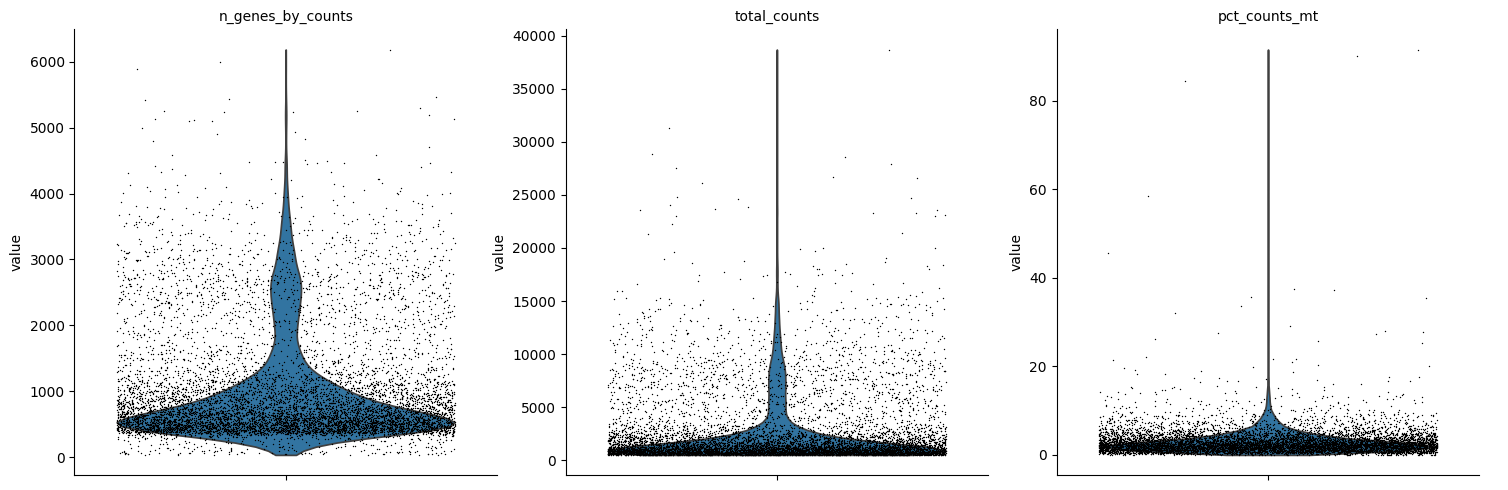

In [3]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='_qc.png')

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\3811793782.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='_mito.png')


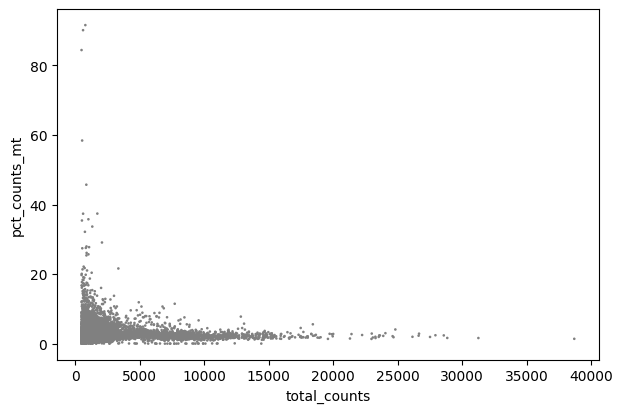

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\3811793782.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_genes.png')


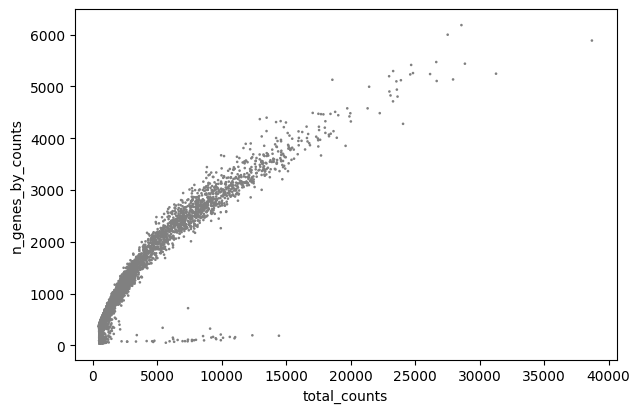

In [4]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='_mito.png')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_genes.png')

In [5]:
# Summary stats to guide threshold selection
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

       n_genes_by_counts  total_counts  pct_counts_mt
count        8484.000000   8484.000000    8484.000000
mean         1011.703795   2487.094238       2.931056
std           840.367852   3264.450195       3.122848
min            34.000000    500.000000       0.000000
25%           482.000000    751.000000       1.392332
50%           680.000000   1172.000000       2.288443
75%          1132.000000   2342.750000       3.576983
max          6184.000000  38701.000000      91.572327


## 3. Filter low-quality cells

Cell Ranger 10 called 8,484 cells vs the paper's ~2,491. The extra calls are low-quality droplets.  
We apply stricter `min_genes` than Cherief (uninjured tissue has less ambient RNA noise).

In [6]:
print('Before filtering:', adata.n_obs)

sc.pp.filter_cells(adata, min_genes=700)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 15].copy()
adata = adata[adata.obs['n_genes_by_counts'] < 5000].copy()

print('After filtering: ', adata.n_obs)

Before filtering: 8484
filtered out 4393 cells that have less than 700 genes expressed
filtered out 14533 genes that are detected in less than 3 cells
After filtering:  4069


## 4. Normalize and embed

normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes
    finished (0:00:01)


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:01)


C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\3123552364.py:12: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata, n_pcs=30, save='.png')


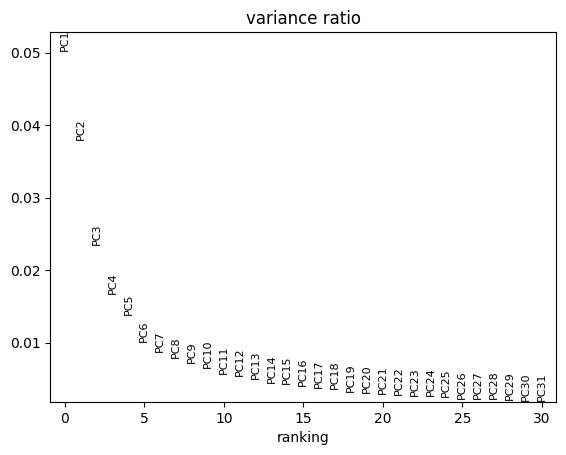

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store log-normalised counts before scaling — used later for interpretable expression values
adata.raw = adata

# No batch_key — single sample
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, n_pcs=30, save='.png')

In [8]:
sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)
# resolution=0.3 targets ~8 clusters to match Harvey 2019's reported cluster count
sc.tl.leiden(adata, resolution=0.3, flavor='igraph', n_iterations=2, directed=False)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished (0:00:10)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:00)


## 5. Visualize clusters

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\769568995.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color='leiden', legend_loc='on data', save='_clusters.png')


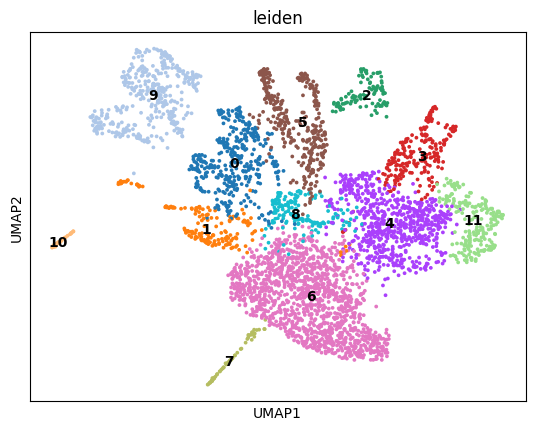

Cluster sizes:
leiden
0      368
1      173
2      103
3      220
4      684
5      341
6     1321
7       65
8      163
9      385
10      33
11     213
Name: count, dtype: int64


In [9]:
sc.pl.umap(adata, color='leiden', legend_loc='on data', save='_clusters.png')
print('Cluster sizes:')
print(adata.obs['leiden'].value_counts().sort_index())

## 6. Key marker genes

From Harvey 2019 Fig. 1 and Extended Data — using the paper's actual cluster definitions:

| Cell type | Harvey cluster | Primary markers |
|---|---|---|
| TSPC | 2 | Tppp3+, Prg4+, subset also Pdgfra+ |
| T-FAP | 3 | Tppp3−, Pdgfra+, Ly6a+ |
| Tenocyte | 4 | Tnmd+, Fmod+, Thbs4+ |

**Key rule: Tppp3 is the single discriminator. High = TSPC, low/absent = T-FAP.**  
Pdgfra is expressed by both populations and cannot separate them alone.

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\988778933.py:17: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, all_markers, groupby='leiden', use_raw=True,


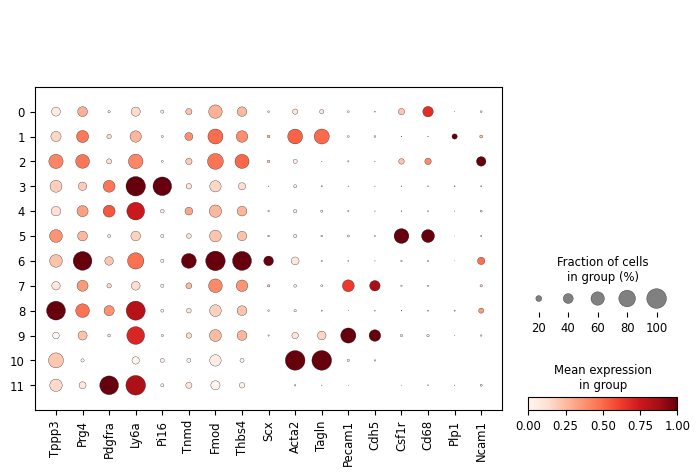

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\988778933.py:19: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(adata, all_markers, groupby='leiden', use_raw=True,


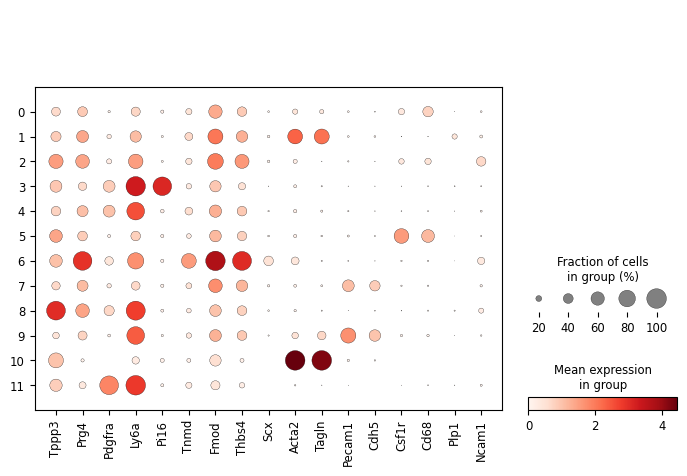

In [10]:
# Harvey 2019 primary markers (from paper Fig. 1 / Extended Data)
# Note: Pdgfra is shared between TSPC (Tppp3+Pdgfra+ subset) and T-FAP (Tppp3-Pdgfra+)
# Pi16 is a secondary T-FAP/FAP2 marker from Scott et al. 2019, not Harvey's primary definition
markers = {
    'TSPC':          ['Tppp3', 'Prg4'],
    'T-FAP':         ['Pdgfra', 'Ly6a', 'Pi16'],
    'Tenocyte':      ['Tnmd', 'Fmod', 'Thbs4', 'Scx'],
    'Smooth muscle': ['Acta2', 'Tagln'],
    'Endothelial':   ['Pecam1', 'Cdh5'],
    'Macrophage':    ['Csf1r', 'Cd68'],
    'Nerve':         ['Plp1', 'Ncam1'],
}

all_markers = list(dict.fromkeys(g for genes in markers.values() for g in genes))
all_markers = [g for g in all_markers if g in adata.raw.var_names]

sc.pl.dotplot(adata, all_markers, groupby='leiden', use_raw=True,
              standard_scale='var', save='_markers.png')
sc.pl.dotplot(adata, all_markers, groupby='leiden', use_raw=True,
              save='_markers_raw.png')

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\2918323062.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color=['Tppp3', 'Prg4', 'Pdgfra', 'Ly6a', 'Tnmd', 'Fmod'],


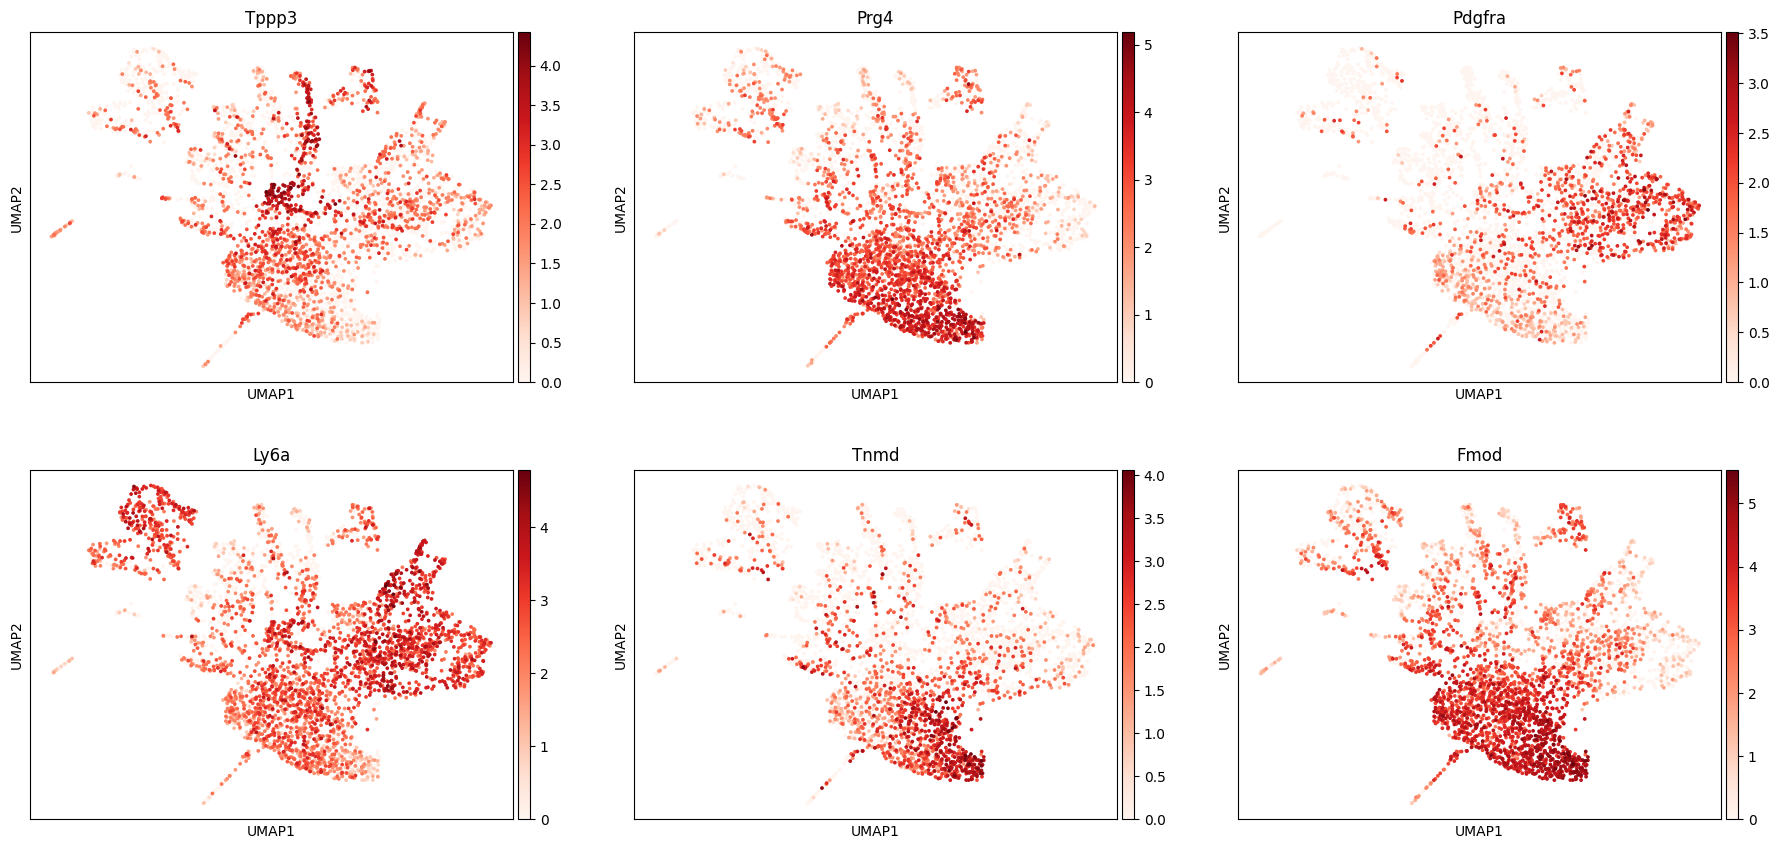

In [11]:
# Feature UMAPs using raw log-normalised counts
# Tppp3 + Prg4 = TSPC; Pdgfra + Ly6a = T-FAP; Tnmd + Fmod = Tenocyte
sc.pl.umap(adata, color=['Tppp3', 'Prg4', 'Pdgfra', 'Ly6a', 'Tnmd', 'Fmod'],
           ncols=3, use_raw=True, cmap='Reds', save='_markers.png')

## 7. Confirm TSPC and T-FAP clusters

Harvey 2019 definitions (directly from the paper):
- **TSPC** (cluster 2): Tppp3+ Prg4+ — the regeneration-competent subset is also Pdgfra+
- **T-FAP** (cluster 3): Tppp3− Pdgfra+ Ly6a+

**Annotation rule:**
1. Find the cluster(s) with highest Tppp3 → TSPC
2. Among Tppp3-low clusters, find the one with highest Pdgfra + Ly6a → T-FAP
3. Tnmd+/Fmod+ clusters → Tenocyte
4. Everything else by process of elimination

The `cluster_means` below uses raw log-normalised expression (not scaled z-scores),
so the numbers are directly interpretable.

In [12]:
# Per-cluster mean expression on log-normalised counts (adata.raw)
# Values are interpretable: ~0 = not expressed, >1 = clearly expressed
key_genes = ['Tppp3', 'Prg4', 'Pdgfra', 'Ly6a', 'Pi16', 'Tnmd', 'Fmod']
key_genes = [g for g in key_genes if g in adata.raw.var_names]

import numpy as np
raw_expr = pd.DataFrame(
    adata.raw[:, key_genes].X.toarray() if hasattr(adata.raw[:, key_genes].X, 'toarray')
    else np.array(adata.raw[:, key_genes].X, dtype=float),
    index=adata.obs_names,
    columns=key_genes
).astype(float)

cluster_means = (
    raw_expr
    .assign(leiden=adata.obs['leiden'].values)
    .groupby('leiden', observed=True)
    .mean()
    .round(3)
)
print(cluster_means)

print('\n--- TSPC candidates (ranked by Tppp3) ---')
print(cluster_means[['Tppp3', 'Prg4']].sort_values('Tppp3', ascending=False).head(4))

# T-FAP: ranked by Ly6a — Harvey's primary definition is Tppp3- Pdgfra+ Ly6a+
# Pi16 is a secondary marker (Scott et al.) and missed cluster 11 when used for ranking
print('\n--- T-FAP candidates (ranked by Ly6a, Harvey primary marker) ---')
print(cluster_means[['Tppp3', 'Pdgfra', 'Ly6a', 'Pi16']].sort_values('Ly6a', ascending=False).head(5))

print('\n--- Tenocyte candidates (ranked by Tnmd) ---')
print(cluster_means[['Tnmd', 'Fmod']].sort_values('Tnmd', ascending=False).head(4))

        Tppp3   Prg4  Pdgfra   Ly6a   Pi16   Tnmd   Fmod
leiden                                                  
0       0.627  0.896   0.101  0.704  0.171  0.450  1.341
1       0.859  1.383   0.248  1.080  0.095  0.671  2.052
2       1.523  1.410   0.236  1.508  0.106  0.417  1.969
3       0.929  0.644   0.848  3.300  3.099  0.283  0.931
4       0.765  1.047   1.015  2.549  0.205  0.578  1.284
5       1.410  0.843   0.137  0.803  0.173  0.287  1.137
6       1.027  2.936   0.397  1.704  0.125  1.555  3.752
7       0.667  1.104   0.286  0.676  0.121  0.490  1.739
8       3.014  1.428   0.695  2.749  0.138  0.264  0.995
9       0.456  0.742   0.125  2.389  0.095  0.339  1.236
10      0.994  0.093   0.000  0.271  0.130  0.127  0.568
11      0.834  0.324   1.846  2.828  0.119  0.269  0.406

--- TSPC candidates (ranked by Tppp3) ---
        Tppp3   Prg4
leiden              
8       3.014  1.428
2       1.523  1.410
5       1.410  0.843
6       1.027  2.936

--- T-FAP candidates (ranked by 

## 8. Annotate clusters

C:\Users\fangy\AppData\Local\Temp\ipykernel_37920\2616916403.py:32: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata, color='cell_type', legend_loc='on data', save='_annotated.png')


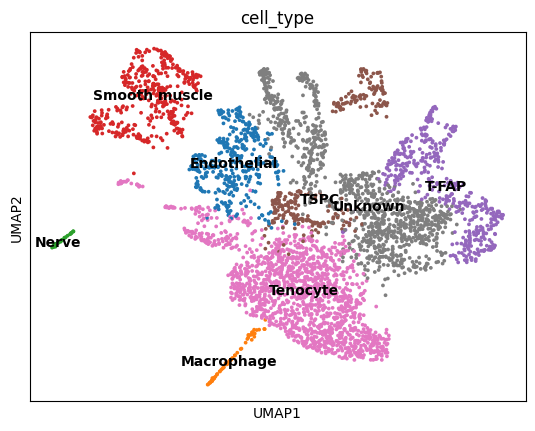


Cell type counts:
cell_type
Tenocyte         1494
Unknown          1025
T-FAP             433
Smooth muscle     385
Endothelial       368
TSPC              266
Macrophage         65
Nerve              33
Name: count, dtype: int64


In [13]:
# Annotation based on cluster_means + dotplot
# High-confidence assignments only — ambiguous clusters left as Unknown
#
# TSPC:     8 (Tppp3=3.01, highest), 2 (Tppp3=1.52 + Prg4=1.41, co-elevated)
# T-FAP:    3 (Pi16=3.10, Ly6a=3.30, both dominant), 11 (Pdgfra=1.85, Ly6a=2.83, Harvey primary def)
# Tenocyte: 6 (Fmod=3.75, Tnmd=1.55), 1 (Fmod=2.05, Tnmd=0.67)
# Non-stromal from dotplot:
#   Endothelial:   0 (Pecam1+, Cdh5+)
#   Macrophage:    7 (Csf1r+, Cd68+)
#   Smooth muscle: 9 (Acta2+, Tagln+)
#   Nerve:         10 (Plp1+, Ncam1+; Pdgfra=0 confirms non-stromal)
# Unknown — excluded from classifier training:
#   5: Tppp3=1.41 but Prg4 too weak to confirm TSPC
#   4: appears in both T-FAP and Tenocyte rankings, genuinely ambiguous

cluster_annotation = {
    '8':  'TSPC',
    '2':  'TSPC',
    '3':  'T-FAP',
    '11': 'T-FAP',
    '6':  'Tenocyte',
    '1':  'Tenocyte',
    '0':  'Endothelial',
    '7':  'Macrophage',
    '9':  'Smooth muscle',
    '10': 'Nerve',
    '5':  'Unknown',
    '4':  'Unknown',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotation).astype('category')
sc.pl.umap(adata, color='cell_type', legend_loc='on data', save='_annotated.png')
print('\nCell type counts:')
print(adata.obs['cell_type'].value_counts())

## 9. Validate annotations with DEG analysis

Run Wilcoxon rank-sum test comparing TSPC vs T-FAP (each against the rest).  
If annotations are correct, top DEGs should match Harvey's paper: Tppp3 for TSPC, Ly6a/Pdgfra/Pi16 for T-FAP.

ranking genes
    finished (0:00:00)


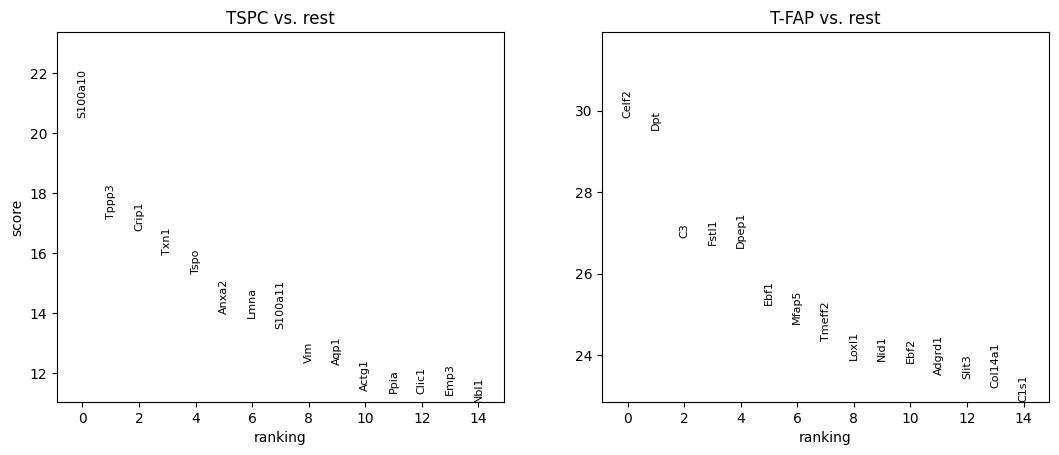


--- Top DEGs: TSPC vs rest ---
  names  logfoldchanges    pvals_adj
S100a10        1.795270 2.645058e-89
  Tppp3        2.954417 5.614588e-62
  Crip1        1.396122 4.328934e-59
   Txn1        1.731113 1.256357e-53
   Tspo        1.670416 2.265411e-49
  Anxa2        1.198929 6.515927e-41
   Lmna        1.221964 4.054604e-40
S100a11        1.205681 4.501752e-38
    Vim        0.878832 8.690311e-32
   Aqp1        2.203505 2.552699e-31
  Actg1        0.949157 5.356651e-27
   Ppia        0.740986 1.017535e-26
  Clic1        1.284476 1.249138e-26
   Emp3        1.123829 1.752155e-26
   Nbl1        1.452975 2.476559e-25

--- Top DEGs: T-FAP vs rest ---
  names  logfoldchanges     pvals_adj
  Celf2        4.505476 2.554391e-191
    Dpt        4.302316 9.297572e-188
     C3        4.100095 2.853926e-155
  Fstl1        2.793172 1.313898e-153
  Dpep1        5.616230 1.079558e-152
   Ebf1        3.478966 6.582627e-137
  Mfap5        3.869260 5.422106e-132
 Tmeff2        5.894655 1.566191e-127
 

In [14]:
# Exclude Unknown cells from DEG analysis
adata_labeled = adata[adata.obs['cell_type'] != 'Unknown'].copy()

sc.tl.rank_genes_groups(
    adata_labeled,
    groupby='cell_type',
    groups=['TSPC', 'T-FAP'],
    reference='rest',
    method='wilcoxon',
    use_raw=True
)
sc.pl.rank_genes_groups(adata_labeled, groups=['TSPC', 'T-FAP'], n_genes=15, sharey=False)

# Print top genes numerically for easy reading
import pandas as pd
for group in ['TSPC', 'T-FAP']:
    result = sc.get.rank_genes_groups_df(adata_labeled, group=group).head(15)
    print(f'\n--- Top DEGs: {group} vs rest ---')
    print(result[['names', 'logfoldchanges', 'pvals_adj']].to_string(index=False))

## 10. Save

In [15]:
adata.write('../../data/Harvey_scRNA-seq/harvey2019_processed.h5ad')
print('Saved:', adata.n_obs, 'cells')

Saved: 4069 cells
